In [84]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from RaTag.core.datatypes import Run, SetPmt
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig

from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.el_tpc.drift_workflow import map_drift_physics
from RaTag.el_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.el_tpc.recoil_workflow import map_recoil_integration, resolve_set_recoils, map_recoil_fits, map_recoil_plots

%matplotlib inline

# Initialize test run and set

In [86]:
# pattern = '/Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN31_EL20k/FieldScan_Gate0672_Anode1472/RUN31_20260702_Gate0672_Anode1472_P14'
# files = glob.glob(f"{pattern}*.wfm")
# filenames = [os.path.basename(f) for f in files]
# for i, file in enumerate(files):
#     os.rename(file, f"{pattern}_{i}Wfm.wfm")    

In [87]:
# raw_data_path = '/Users/pabloherrero/sabat/RaTagging/test_data/raw_data/RUN8/'
# raw_data_path = "/Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN8_EL2350Vcm_5GSsec"
# config_path = '/Users/pabloherrero/sabat/RaTagging/test_data/configs/run8_analysis.yaml'
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run8_analysis.yaml'


bare_run = bootstrap_from_config(config_path)

Found 13 directories in RUN8_EL2350Vcm_5GSsec
  🔹 Bootstrapping Alpha Set from: Ch4_SCA_4-4p8 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: Ch4_SCA_4p8-5p4 with 50 waveforms.
  🔹 Bootstrapping Alpha Set from: Ch4_noSCA with 300 waveforms.
  → Bootstrapped 9 PMT Sets and 3 Alpha Sets.


In [88]:
set0 = bare_run.sets[0]
print(set0)

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN8_EL2350Vcm_5GSsec/FieldScan_Gate0050_Anode1950
  filenames = <2037 files, 97776 waveforms, FastFrame(48 frames/file)>
  multiiso = False
  ff = True
  nframes = 48
  gate = 50
  anode = 1950

  Missing:
    sampling_rate, drift_field, EL_field, red_drift_field, red_EL_field, speed_drift, time_drift, diffusion_coefficient, baseline_median, baseline_std, t_s1, t_s1_std, t_s2_start, t_s2_start_std, t_s2_end, t_s2_end_std, n_areas_recoil, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success


# Set drift properties

In [89]:
run = map_drift_physics(bare_run, force=False)
set0 = run.sets[0]

  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0050_Anode1950'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0050_Anode1950'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0050_Anode1950'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0100_Anode2000'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0100_Anode2000'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0100_Anode2000'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0200_Anode2100'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0200_Anode2100'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0200_Anode2100'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0300_Anode2200'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0300_Anode2200'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0300_Anode2200'
  📂 Cache Hit: Loaded metada

In [90]:
print(set0)

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN8_EL2350Vcm_5GSsec/FieldScan_Gate0050_Anode1950
  filenames = <2037 files, 97776 waveforms, FastFrame(48 frames/file)>
  multiiso = False
  ff = True
  nframes = 48
  gate = 50
  anode = 1950
  drift_field = 35.714
  EL_field = 2375.0
  red_drift_field = 0.073
  red_EL_field = 4.869
  speed_drift = 0.701
  time_drift = 19.976
  t_s1 = -3.304
  t_s1_std = 1.849
  t_s2_start = 14.72
  t_s2_start_std = 2.155
  t_s2_end = 27.257
  t_s2_end_std = 3.187

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std, n_areas_recoil, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success


# Test new timing_workflow

## Individual sets

In [91]:
set8 = run.sets[7]
set8t = resolve_set_timing(set8, max_frames=400, config=TimingConfig(), force=True)

  ✓ FieldScan_Gate0800_Anode2700: Computed 't_s2_end' and stored metadata


## Full run

In [92]:
runt = map_time_windows(run, max_frames=400, config=TimingConfig(), force=False)

  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0050_Anode1950'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0100_Anode2000'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0200_Anode2100'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0300_Anode2200'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0400_Anode2300'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0500_Anode2400'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0600_Anode2500'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate0800_Anode2700'
  📂 Cache Hit: Loaded metadata for 't_s2_end in FieldScan_Gate1100_Anode3000'


In [93]:
runt.sets[-1]

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN8_EL2350Vcm_5GSsec/FieldScan_Gate1100_Anode3000
  filenames = <2000 files, 96000 waveforms, FastFrame(48 frames/file)>
  multiiso = False
  ff = True
  nframes = 48
  gate = 1100
  anode = 3000
  drift_field = 785.714
  EL_field = 2375.0
  red_drift_field = 1.611
  red_EL_field = 4.869
  speed_drift = 1.483
  time_drift = 9.438
  t_s1 = -2.527
  t_s1_std = 0.636
  t_s2_start = 9.317
  t_s2_start_std = 1.242
  t_s2_end = 12.085
  t_s2_end_std = 0.827

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std, n_areas_recoil, area_s2_mean, area_s2_sigma, area_s2_ci95, area_s2_fit_success

## Plot timing results

In [94]:
runt = map_timing_plots(runt, force=True)


GENERATING TIMING PLOTS: RUN8
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN8_EL2350Vcm_5GSsec/plots/timing_qa/RUN8_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN8_EL2350Vcm_5GSsec/plots/timing_qa/RUN8_validation.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN8_EL2350Vcm_5GSsec/plots/timing_qa/RUN8_timing_vs_field.png


# Integration pipeline

In [96]:
integ_dict = {
    'n_sigma_start': 2,
    'n_sigma_end': 2,
    'n_pedestal': 200,
    'ma_window': 9,
    'bs_threshold': 0.03,
    'dt': 2e-4
}

integ_config = IntegrationConfig(**integ_dict)

fit_config = FitConfig(
    bin_cuts=(0, 10),
    nbins=100,
    exclude_index=1,
    bg_threshold=0.5,
    bg_cutoff=0.07,
    n_sigma=3.,
    upper_limit=5.0)

In [98]:
runi = map_recoil_integration(runt, max_frames=None, config=integ_config, force=False)


INTEGRATING S2 RECOILS: RUN8
  Integrating set FieldScan_Gate0050_Anode1950 with Static Window: [10.41, 33.63] µs
  🔹 Processed 2037 waveforms for S2 area integration.
  ✓ FieldScan_Gate0050_Anode1950: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0100_Anode2000 with Static Window: [8.11, 18.31] µs
  🔹 Processed 2008 waveforms for S2 area integration.
  ✓ FieldScan_Gate0100_Anode2000: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0200_Anode2100 with Static Window: [9.36, 16.76] µs
  🔹 Processed 2000 waveforms for S2 area integration.
  ✓ FieldScan_Gate0200_Anode2100: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0300_Anode2200 with Static Window: [8.83, 15.91] µs
  🔹 Processed 2000 waveforms for S2 area integration.
  ✓ FieldScan_Gate0300_Anode2200: Computed 'n_areas_recoil' and stored metadata
  Integrating set FieldScan_Gate0400_Anode2300 with Static Window: [8.58, 15.23] µs
  🔹 Processed

In [ ]:
# from RaTag.io import file_ops
# from dataclasses import replace

# for s in runi.sets:
#     s2_areas = file_ops.load_npz_arrays(s, signal_type='s2_areas')
#     print(f"Set {s.source_dir.name}: s2_areas shape: {s2_areas['s2_areas'].shape}")
#     updated_set = replace(s, n_areas_recoil=len(s2_areas['s2_areas']))

#     file_ops.save_cache(updated_set)

Set FieldScan_Gate0050_Anode2750: s2_areas shape: (19200,)
Set FieldScan_Gate0100_Anode2800: s2_areas shape: (19200,)
Set FieldScan_Gate0200_Anode2900: s2_areas shape: (19200,)
Set FieldScan_Gate0300_Anode3000: s2_areas shape: (19200,)
Set FieldScan_Gate0500_Anode3200: s2_areas shape: (19200,)
Set FieldScan_Gate0700_Anode3400: s2_areas shape: (19200,)
Set FieldScan_Gate1000_Anode3700: s2_areas shape: (19200,)
Set FieldScan_Gate1200_Anode3900: s2_areas shape: (19200,)


## Fits s2 area histograms

In [ ]:
runif = map_recoil_fits(runi, config=fit_config, force=True)


FITTING S2 AREA DISTRIBUTIONS: RUN_31
  Fit success: True, χ²/DOF: 3878.92
  ✓ Fit: μ=3.032 ± 0.057 mV·µs
  ✓ FieldScan_Gate0048_Anode0848: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 158.61
  ✓ Fit: μ=3.336 ± 0.081 mV·µs
  ✓ FieldScan_Gate0072_Anode0872: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 187.50
  ✓ Fit: μ=3.606 ± 0.089 mV·µs
  ✓ FieldScan_Gate0096_Anode0896: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 98.27
  ✓ Fit: μ=3.707 ± 0.119 mV·µs
  ✓ FieldScan_Gate0120_Anode0920: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 191.09
  ✓ Fit: μ=3.857 ± 0.099 mV·µs
  ✓ FieldScan_Gate0144_Anode0944: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 129.81
  ✓ Fit: μ=4.265 ± 0.057 mV·µs
  ✓ FieldScan_Gate0188_Anode0988: Computed 'area_s2_fit_success' and stored metadata
  Fit success: True, χ²/DOF: 148.50
  ✓ Fit: μ=4.

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:17: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


In [ ]:
set7f = runif.sets[7]
set7f

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN26_Th228_EL2700/FieldScan_Gate1200_Anode3900
  filenames = <400 files, 19200 waveforms, FastFrame(48 frames/file)>
  multiiso = False
  ff = True
  nframes = 48
  gate = 1200
  anode = 3900
  drift_field = 857.143
  EL_field = 3375.0
  red_drift_field = 1.757
  red_EL_field = 6.92
  speed_drift = 1.516
  time_drift = 9.232
  t_s1 = -3.257
  t_s1_std = 1.625
  t_s2_start = 8.146
  t_s2_start_std = 1.157
  t_s2_end = 10.59
  t_s2_end_std = 0.473
  n_areas_recoil = 19200
  area_s2_mean = 3.3671614158536
  area_s2_sigma = 2.6434483516549876
  area_s2_ci95 = 0.09544407993506179
  area_s2_fit_success = True

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std

In [ ]:
map_recoil_plots(runif, force=True)


GENERATING RECOIL S2 AREAS QA PLOTS: RUN_31
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN31_EL20k/plots/s2_areas/RUN_31_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN31_EL20k/plots/s2_areas/RUN_31_s2_vs_field.png


Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN31_EL20k
  run_id = RUN_31
  el_field = 20000.0
  multiiso = False
  target_isotope = Th228
  pressure = 1.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.04
  drift_gap = 0.48
  sets = <13 SetPmt objects>
  alpha_sets = [SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN31_EL20k/Ch4_SCA_4p0-4p7
  filenames = <6 files, 2958 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a, calib_b, calib_c, calib_order, mean_energy_resolution, isotope_ranges_V, isotope_ranges_E, SetAlpha state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN31_EL20k/Ch4_SCA_4p0-5p0
  filenames = <6 files, 2958 waveforms, FastFrame(493 frames/file)>
  multiiso = False
  ff = True
  nframes = 493

  Missing:
    gate, anode, sampling_rate, n_alpha_energies, calib_a, calib_b, calib_c, cali

# X-ray workflow

In [ ]:
from RaTag.el_tpc.xray_workflow import (map_xrays_events, resolve_set_xrays, aggregate_run_xrays,
                                        fit_xray_events, make_xray_plots, calculate_xray_calibration,
                                        _load_xray_plot_data,)
from RaTag.core.config import XRayConfig
from RaTag.io.file_ops import load_npz_arrays, load_s2areas_from_path

In [ ]:
config_path21 = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run21_analysis_xray.yaml'
run21 = bootstrap_from_config(config_path21)
run21 = map_drift_physics(run21, force=True)


Found 6 directories in RUN21_xrays
  → Bootstrapped 6 PMT Sets and 0 Alpha Sets.
  ✓ FieldScan_Gate100_Anode2000_batch1: Computed 'drift_field' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch1: Computed 'red_EL_field' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch1: Computed 'time_drift' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch2: Computed 'drift_field' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch2: Computed 'red_EL_field' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch2: Computed 'time_drift' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch3: Computed 'drift_field' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch3: Computed 'red_EL_field' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch3: Computed 'time_drift' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch4: Computed 'drift_field' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch4: Computed 'red_EL_field' and stored metadata
  ✓ F

In [ ]:
run21 = map_time_windows(run21, max_frames=400, config=TimingConfig(), force=False)
map_timing_plots(run21, force=False)

  📂 FieldScan_Gate100_Anode2000_batch1: Loaded 'timing' arrays from disk
  ✓ FieldScan_Gate100_Anode2000_batch2: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch3: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch4: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch5: Computed 't_s2_end' and stored metadata
  ✓ FieldScan_Gate100_Anode2000_batch6: Computed 't_s2_end' and stored metadata
  ⏭ Skipping plots for RUN21 (already exist)


Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN21_xrays
  run_id = RUN21
  el_field = 2350.0
  multiiso = False
  target_isotope = Th228
  pressure = 2.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.8
  drift_gap = 1.4
  sets = <6 SetPmt objects>
  alpha_sets = []
  gas_density = 4.877421222922505e+19
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    g_S2, alpha_calibration, isotope_ranges

In [ ]:
for s in run21.sets[1:]:
    s.t_s1 = run21.sets[0].t_s1
    s.t_s1_std = run21.sets[0].t_s1_std
    s.t_s2_start = run21.sets[0].t_s2_start
    s.t_s2_start_std = run21.sets[0].t_s2_start_std
    s.t_s2_end = run21.sets[0].t_s2_end
    s.t_s2_end_std = run21.sets[0].t_s2_end_std



In [ ]:
run21x = map_xrays_events(run21, max_frames=None, config=XRayConfig(), force=False)


IDENTIFYING X-RAY EVENTS: RUN21
  📂 FieldScan_Gate100_Anode2000_batch1: Loaded 'xray_areas' arrays from disk
  📂 FieldScan_Gate100_Anode2000_batch2: Loaded 'xray_areas' arrays from disk
  📂 FieldScan_Gate100_Anode2000_batch3: Loaded 'xray_areas' arrays from disk
  📂 FieldScan_Gate100_Anode2000_batch4: Loaded 'xray_areas' arrays from disk
  📂 FieldScan_Gate100_Anode2000_batch5: Loaded 'xray_areas' arrays from disk
  📂 FieldScan_Gate100_Anode2000_batch6: Loaded 'xray_areas' arrays from disk
  Aggregating run-level X-ray areas...
      Loaded 200 X-ray events from set FieldScan_Gate100_Anode2000_batch1
      Loaded 2946 X-ray events from set FieldScan_Gate100_Anode2000_batch2
      Loaded 3828 X-ray events from set FieldScan_Gate100_Anode2000_batch3
      Loaded 3893 X-ray events from set FieldScan_Gate100_Anode2000_batch4
      Loaded 3050 X-ray events from set FieldScan_Gate100_Anode2000_batch5
      Loaded 4415 X-ray events from set FieldScan_Gate100_Anode2000_batch6


In [ ]:
aggregate_run_xrays(run21x, )

  Aggregating run-level X-ray areas...
      Loaded 200 X-ray events from set FieldScan_Gate100_Anode2000_batch1
      Loaded 2946 X-ray events from set FieldScan_Gate100_Anode2000_batch2
      Loaded 3828 X-ray events from set FieldScan_Gate100_Anode2000_batch3
      Loaded 3893 X-ray events from set FieldScan_Gate100_Anode2000_batch4
      Loaded 3050 X-ray events from set FieldScan_Gate100_Anode2000_batch5
      Loaded 4415 X-ray events from set FieldScan_Gate100_Anode2000_batch6


Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN21_xrays
  run_id = RUN21
  el_field = 2350.0
  multiiso = False
  target_isotope = Th228
  pressure = 2.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.8
  drift_gap = 1.4
  sets = <6 SetPmt objects>
  alpha_sets = []
  gas_density = 4.877421222922505e+19
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    g_S2, alpha_calibration, isotope_ranges

In [ ]:
run21f = fit_xray_events(run21x, config=FitConfig(n_sigma=3, ),)


FITTING COMBINED X-RAY AREA: RUN21
  Fit success: True, χ²/DOF: 230.29
  ✓ Fit: μ=1.852 ± 0.023 mV·µs



GENERATING X-RAY QA PLOTS: RUN21
  Loaded combined X-ray areas: 18332 events
  ⚠ Plot generation failed: float() argument must be a string or a number, not 'NoneType'


Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN21_xrays
  run_id = RUN21
  el_field = 2350.0
  multiiso = False
  target_isotope = Th228
  pressure = 2.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.8
  drift_gap = 1.4
  sets = <6 SetPmt objects>
  alpha_sets = []
  gas_density = 4.877421222922505e+19
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    g_S2, alpha_calibration, isotope_ranges

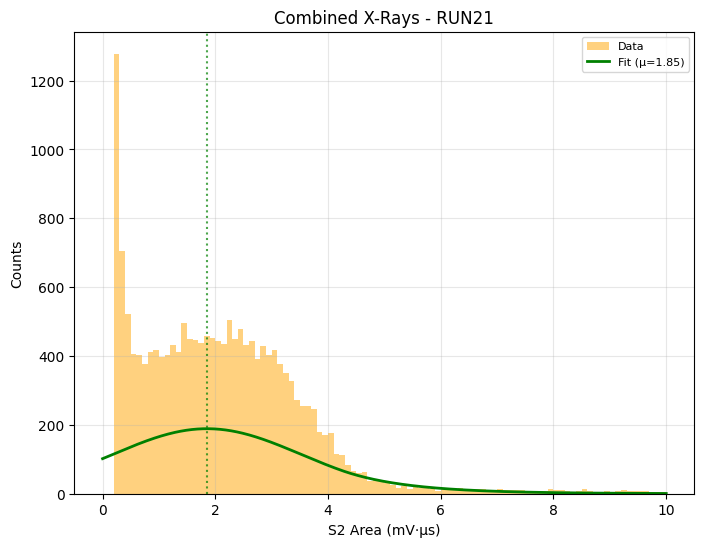

In [ ]:
make_xray_plots(run21f, )

In [ ]:
calculate_xray_calibration(run21f, )


CALCULATING S2 CALIBRATION (g_S2): RUN21
  ✓ Calibration saved: g_S2 = 0.0033 ± 0.0002 mV·µs/e-


Run state:
  root_directory = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN21_xrays
  run_id = RUN21
  el_field = 2350.0
  multiiso = False
  target_isotope = Th228
  pressure = 2.0
  temperature = 297.0
  sampling_rate = 5.0e9
  el_gap = 0.8
  drift_gap = 1.4
  sets = <6 SetPmt objects>
  alpha_sets = []
  gas_density = 4.877421222922505e+19
  width_s2 = 1.1
  t_s1 = 0.0
  recoil_energy = 96.8
  W_value = 22.0
  E_gamma_xray = 12300.0

  Missing:
    g_S2, alpha_calibration, isotope_ranges

In [ ]:
wf.t[1] - wf.t[0]

np.float64(0.00039999999999906777)